In [1]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Fix Random Seed 
seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)

# File Path Configuration
ATHLETE_FILE = r"C:\Users\10759\Desktop\summerOly_athletes.csv"
MEDAL_FILE   = r"C:\Users\10759\Desktop\summerOly_medal_counts.csv"
SAVE_EXCEL   = r"C:\Users\10759\Desktop\forecast_results_2028_ml.xlsx"

# Read and Filter Athlete Data (Keep only athletes from year 2000 onwards)
athletes_data = pd.read_csv(ATHLETE_FILE)
athletes_data = athletes_data[athletes_data['Year'] >= 2000]

if 'Team' not in athletes_data.columns:
    raise ValueError("'Team' column not found in athlete data, please check file structure.")

# Get unique list of Teams
valid_teams = athletes_data['Team'].unique().tolist()
print("Number of valid Teams from athlete data (Year>=2000):", len(valid_teams))

# Read and Preprocess Medal Data 
medal_data = pd.read_csv(MEDAL_FILE)
# Keep only key columns, aggregate by Year + NOC
medal_data = medal_data[['Year', 'NOC', 'Gold', 'Silver', 'Bronze', 'Total']]
country_year_medals = medal_data.groupby(['Year', 'NOC']).sum().reset_index()
country_year_medals.fillna(0, inplace=True)

print("Shape before filtering:", country_year_medals.shape)

# Filter: 'NOC' in medal data must be in 'Team' list from athlete data
country_year_medals = country_year_medals[country_year_medals['NOC'].isin(valid_teams)]
country_year_medals.reset_index(drop=True, inplace=True)

print("Shape after filtering:", country_year_medals.shape)
print(country_year_medals.head(10))

# Machine Learning Prediction Functions 
def prepare_features(data):
    """Prepare features: use past 3 years' data as features"""
    features = []
    targets = []
    for i in range(3, len(data)):
        features.append(data[i-3:i])
        targets.append(data[i])
    return np.array(features), np.array(targets)

def train_and_predict(X_train, y_train, X_test, method='linear'):
    """Train model and predict"""
    if method == 'linear':
        model = LinearRegression()
    elif method == 'xgb':
        model = XGBRegressor(random_state=seed_value, n_estimators=100)
    elif method == 'rf':
        model = RandomForestRegressor(random_state=seed_value, n_estimators=100)
    else:
        raise ValueError("Unknown method")
    
    model.fit(X_train, y_train)
    return model.predict(X_test)

def ml_forecast(data, steps=1, method='linear'):
    """Forecast using machine learning methods"""
    if len(data) < 4:  # Need at least 4 data points (3 features + 1 target)
        return [np.mean(data)] * steps
    
    X, y = prepare_features(data)
    
    # Predict future values
    predictions = []
    last_features = data[-3:].reshape(1, -1)
    
    for _ in range(steps):
        pred = train_and_predict(X, y, last_features, method=method)
        predictions.append(pred[0])
        last_features = np.append(last_features[0, 1:], pred).reshape(1, -1)
    
    return np.array(predictions)

#  Model Evaluation Functions 
def evaluate_model(true_values, predicted_values):
    """
    Return MAE, MSE, RMSE, R2, MAPE
    """
    true_values = np.nan_to_num(true_values, nan=0.0)
    predicted_values = np.nan_to_num(predicted_values, nan=0.0)

    mae = mean_absolute_error(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    if len(true_values) > 1:
        r2 = r2_score(true_values, predicted_values)
    else:
        r2 = float('nan')

    # MAPE calculation needs to avoid division by zero
    non_zero_mask = (true_values != 0)
    if non_zero_mask.sum() == 0:
        mape = float('nan')
    else:
        mape = np.mean(np.abs((true_values[non_zero_mask] - predicted_values[non_zero_mask]) / true_values[non_zero_mask])) * 100

    return mae, mse, rmse, r2, mape

# Prediction Logic
forecast_results = {}
evaluation_records = []

for noc in country_year_medals['NOC'].unique():
    noc_data = country_year_medals[country_year_medals['NOC'] == noc]
    years = noc_data['Year'].values
    total_medals = np.nan_to_num(noc_data['Total'].values, nan=0.0)
    gold_medals = np.nan_to_num(noc_data['Gold'].values, nan=0.0)
    silver_medals = np.nan_to_num(noc_data['Silver'].values, nan=0.0)
    bronze_medals = np.nan_to_num(noc_data['Bronze'].values, nan=0.0)

    data_len = len(total_medals)

    # Leave-one-out Validation 
    if data_len >= 4:  # Need at least 4 data points
        train_total = total_medals[:-1]  # Exclude last record
        test_total = total_medals[-1]    # Last record for testing
        test_year = years[-1]
        
        try:
            # XGBoost for prediction
            pred_test_total = ml_forecast(train_total, steps=1, method='xgb')[0]
            mae_, mse_, rmse_, r2_, mape_ = evaluate_model([test_total], [pred_test_total])
            
            evaluation_records.append({
                'NOC': noc,
                'TestYear': test_year,
                'True_Total': test_total,
                'Pred_Total': pred_test_total,
                'MAE': mae_,
                'MSE': mse_,
                'RMSE': rmse_,
                'R2': r2_,
                'MAPE(%)': mape_,
                'Method': 'XGBoost'
            })
        except Exception as e:
            print(f"Leave-one-out validation failed, NOC={noc}, Error: {e}")

    # Predict 2028 (Main Logic)
    try:
        # Use XGBoost for prediction
        if data_len >= 4:
            pred_total = ml_forecast(total_medals, steps=1, method='xgb')[0]
        else:
            pred_total = np.mean(total_medals) if len(total_medals) > 0 else 0

        # Split by historical gold/silver/bronze ratios
        gold_ratio = np.mean(gold_medals / total_medals, where=(total_medals != 0))
        silver_ratio = np.mean(silver_medals / total_medals, where=(total_medals != 0))
        bronze_ratio = np.mean(bronze_medals / total_medals, where=(total_medals != 0))

        ratio_sum = gold_ratio + silver_ratio + bronze_ratio
        if ratio_sum == 0:
            gold_forecast = silver_forecast = bronze_forecast = 0
        else:
            gold_forecast = pred_total * gold_ratio / ratio_sum
            silver_forecast = pred_total * silver_ratio / ratio_sum
            bronze_forecast = pred_total * bronze_ratio / ratio_sum

        forecast_results[noc] = {
            'Total': gold_forecast + silver_forecast + bronze_forecast,
            'Gold': gold_forecast,
            'Silver': silver_forecast,
            'Bronze': bronze_forecast,
            'Method': 'XGBoost' if data_len >= 4 else 'Average'
        }
    except Exception as e:
        # fallback
        fallback_total = np.mean(total_medals) if len(total_medals) > 0 else 0
        gold_fallback = np.mean(gold_medals) if len(gold_medals) else 0
        silver_fallback = np.mean(silver_medals) if len(silver_medals) else 0
        bronze_fallback = np.mean(bronze_medals) if len(bronze_medals) else 0
        forecast_results[noc] = {
            'Total': fallback_total,
            'Gold': gold_fallback,
            'Silver': silver_fallback,
            'Bronze': bronze_fallback,
            'Method': 'Average'
        }
        print(f"Prediction failed, NOC={noc}, Using average as fallback. Error: {e}")

# Organize and Export Results
# Initialize empty DataFrame with explicit column names and data types
forecast_df = pd.DataFrame(columns=['NOC', 'Total', 'Gold', 'Silver', 'Bronze', 'Method'])

for noc, fc in forecast_results.items():
    # Create temp DataFrame ensuring all columns exist and are not empty
    temp_df = pd.DataFrame({
        'NOC': [noc],
        'Total': [fc.get('Total', 0)],
        'Gold': [fc.get('Gold', 0)],
        'Silver': [fc.get('Silver', 0)],
        'Bronze': [fc.get('Bronze', 0)],
        'Method': [fc.get('Method', 'Unknown')]
    })
    
    # Ensure all columns exist
    for col in ['NOC', 'Total', 'Gold', 'Silver', 'Bronze', 'Method']:
        if col not in temp_df.columns:
            temp_df[col] = None
    
    forecast_df = pd.concat([forecast_df, temp_df], ignore_index=True)

# Save to Excel
forecast_df.to_excel(SAVE_EXCEL, index=False)
print(f"Forecast results saved to: {SAVE_EXCEL}")

Number of valid Teams from athlete data (Year>=2000): 361
Shape before filtering: (1435, 6)
Shape after filtering: (1299, 6)
   Year            NOC  Gold  Silver  Bronze  Total
0  1896      Australia     2       0       0      2
1  1896        Austria     2       1       2      5
2  1896        Denmark     1       2       3      6
3  1896         France     5       4       2     11
4  1896        Germany     6       5       2     13
5  1896  Great Britain     2       3       2      7
6  1896         Greece    10      18      19     47
7  1896        Hungary     2       1       3      6
8  1896    Switzerland     1       2       0      3
9  1896  United States    11       7       2     20


C:\Users\10759\AppData\Local\Temp\ipykernel_43172\840258333.py:219: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  forecast_df = pd.concat([forecast_df, temp_df], ignore_index=True)


Forecast results saved to: C:\Users\10759\Desktop\forecast_results_2028_ml.xlsx


C:\Users\10759\AppData\Local\Temp\ipykernel_43172\3048580837.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


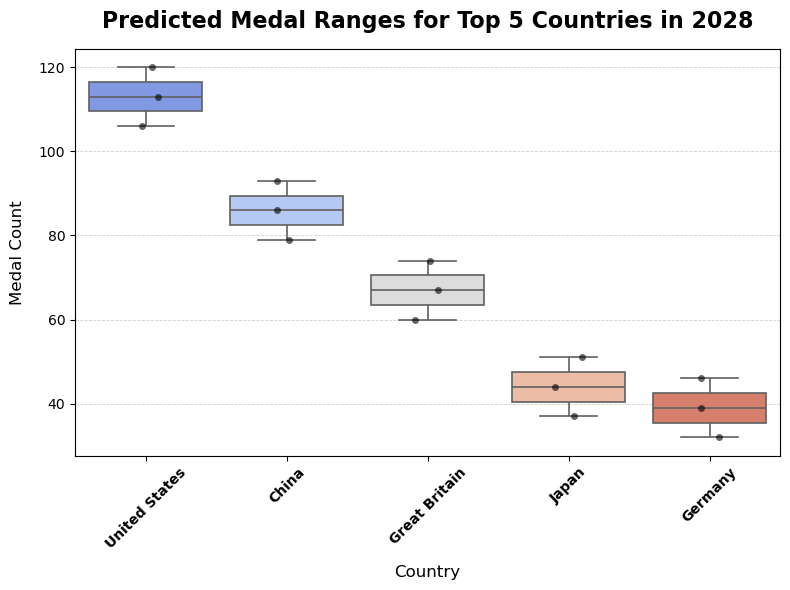

Image saved to C:\Users\10759\Desktop\Predicted_Medal_Boxplot.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load prediction results file
future_data = pd.read_csv(r"C:\Users\10759\Desktop\Predicted_Medal_Table_2028.csv")

# Create data structure for boxplot
data_for_boxplot = future_data.head(5).melt(
    id_vars=['NOC'],
    value_vars=['Total_Lower', 'Predicted_Total', 'Total_Upper'],
    var_name='Type',
    value_name='Medals'
)

# Create sorting order for boxplot comparison
order = future_data.head(5).sort_values('Predicted_Total', ascending=False)['NOC']

# Create boxplot
plt.figure(figsize=(8, 6))  
sns.boxplot(
    x='NOC',
    y='Medals',
    data=data_for_boxplot,
    order=order,
    palette='coolwarm',
    linewidth=1.2  
)

# Add stripplot to show actual values
sns.stripplot(
    x='NOC',
    y='Medals',
    data=data_for_boxplot,
    order=order,
    color='black',
    size=5,  
    jitter=True,  
    alpha=0.6 
)

# Set title and labels
plt.title('Predicted Medal Ranges for Top 5 Countries in 2028', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12, labelpad=10)
plt.ylabel('Medal Count', fontsize=12, labelpad=10)
plt.xticks(rotation=45, fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)

# Add grid lines
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)

# Optimize margins
plt.tight_layout()

# Save the figure
output_path = r'C:\Users\10759\Desktop\Predicted_Medal_Boxplot.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

# Display the plot
plt.show()
print(f"Image saved to {output_path}")


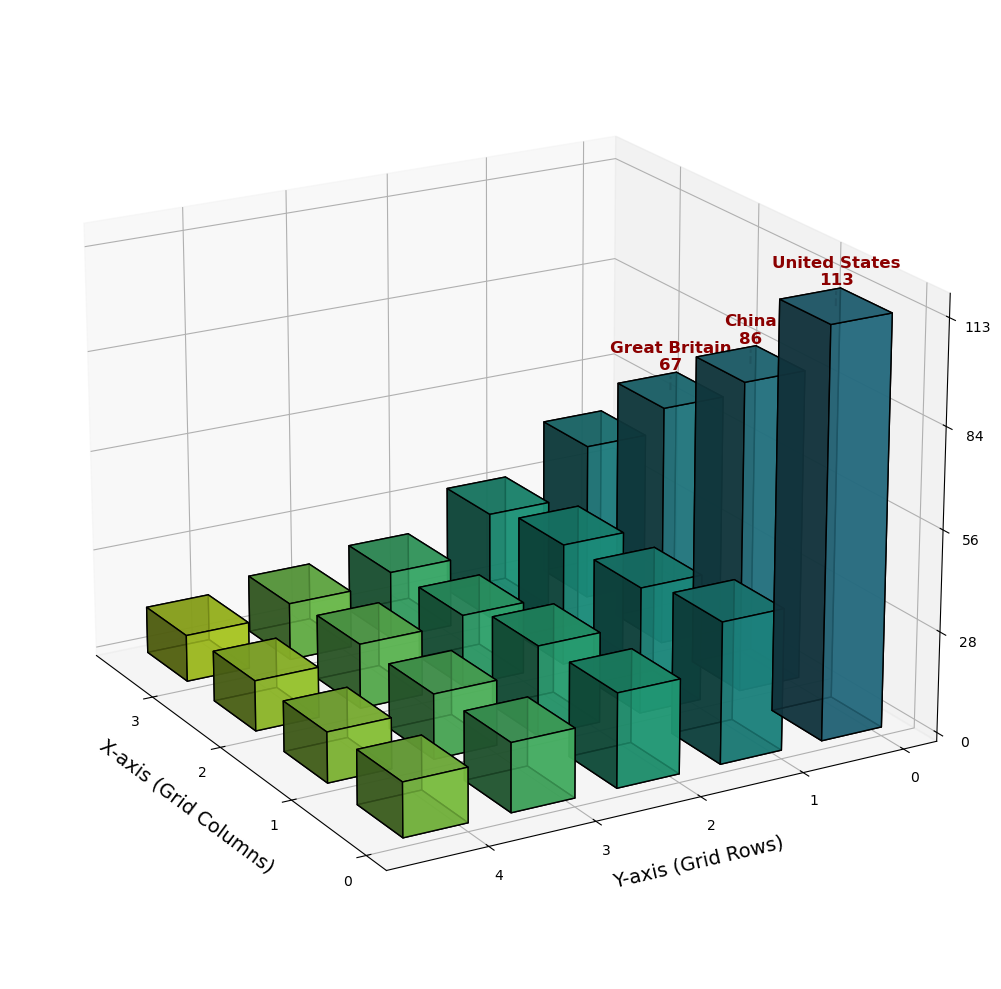

Image saved to: C:\Users\10759\Desktop\top20_median_predictions.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 3D Visualization: Top 20 Countries in 5x4 Grid (Median)
# Read CSV file
csv_path = r"C:\Users\10759\Desktop\Predicted_Medal_Table_2028.csv"
data = pd.read_csv(csv_path) 

# Calculate median values
data['Median'] = (data['Total_Lower'] + data['Total_Upper']) / 2

# Sort by median in descending order and select top 20
top20_df = data.sort_values(by='Median', ascending=False).head(20)

# Extract data
countries = top20_df['NOC'].tolist()  
medians = top20_df['Median'].astype(int).tolist() 

# Define 5x4 grid layout
rows, cols = 5, 4
x_positions, y_positions = np.meshgrid(range(cols), range(rows))

# Adjust bar ordering (highest values innermost)
indices = np.argsort(-np.array(medians))  
x_positions = x_positions.flatten()[indices]
y_positions = y_positions.flatten()[indices] 
medians = np.array(medians)[indices]  
countries = np.array(countries)[indices]  

# Set up figure and 3D axis
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Use soft viridis color scheme
colors = cm.viridis(np.linspace(0.4, 0.9, len(countries)))

# Plot 3D bars
bar_width = 0.6  
depth = 0.6 
for x, y, median, color in zip(x_positions, y_positions, medians, colors):
    ax.bar3d(
        x, y, 0, 
        bar_width, depth, median,  
        color=color, edgecolor='black', alpha=0.8
    )

# Set axis labels
ax.set_xlabel("X-axis (Grid Columns)", fontsize=14, labelpad=10)
ax.set_ylabel("Y-axis (Grid Rows)", fontsize=14, labelpad=10)
ax.set_zlabel("Median Total Medals", fontsize=14, labelpad=15)

# Customize X and Y ticks
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_zticks(np.linspace(0, max(medians), 5, dtype=int))  # Auto-set Z ticks

# Add annotations and arrows for top 3 countries
for i in range(3):  
    x, y, median, country = x_positions[i], y_positions[i], medians[i], countries[i]
    ax.text(
        x + bar_width / 2, y + depth / 2, median + 5,  
        f"{country}\n{median}", color='darkred', fontsize=12, fontweight='bold', ha='center', va='bottom'
    )
    ax.plot(
        [x + bar_width / 2, x + bar_width / 2], [y + depth / 2, y + depth / 2], [median, median + 4],  # Arrow pointing
        color='darkred', linestyle='--', linewidth=1.5
    )

# Set view angle and grid
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax.view_init(elev=20, azim=150) 

# Save image
output_path = r"C:\Users\10759\Desktop\top20_median_predictions.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Image saved to: {output_path}")

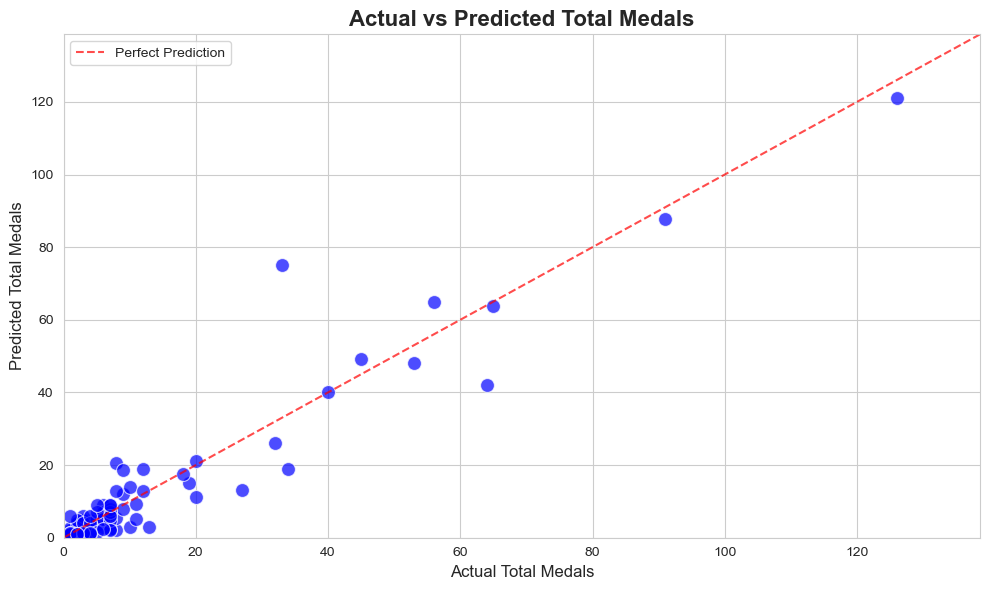

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

eval_df = pd.DataFrame(evaluation_records)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot all scatter points - using consistent blue circles
sns.scatterplot(
    x='True_Total', 
    y='Pred_Total',
    data=eval_df,
    color='blue',  
    s=100,        
    alpha=0.7     
)

# Draw y = x reference line
max_val = max(np.max(eval_df['True_Total']), np.max(eval_df['Pred_Total'])) * 1.1
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='Perfect Prediction')

plt.title("Actual vs Predicted Total Medals", fontsize=16, fontweight='bold')
plt.xlabel("Actual Total Medals", fontsize=12)
plt.ylabel("Predicted Total Medals", fontsize=12)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.tight_layout()

# Only show reference line in legend
plt.legend()

plt.savefig("history_evaluation_True_vs_Pred.png", dpi=300, bbox_inches='tight')
plt.show()

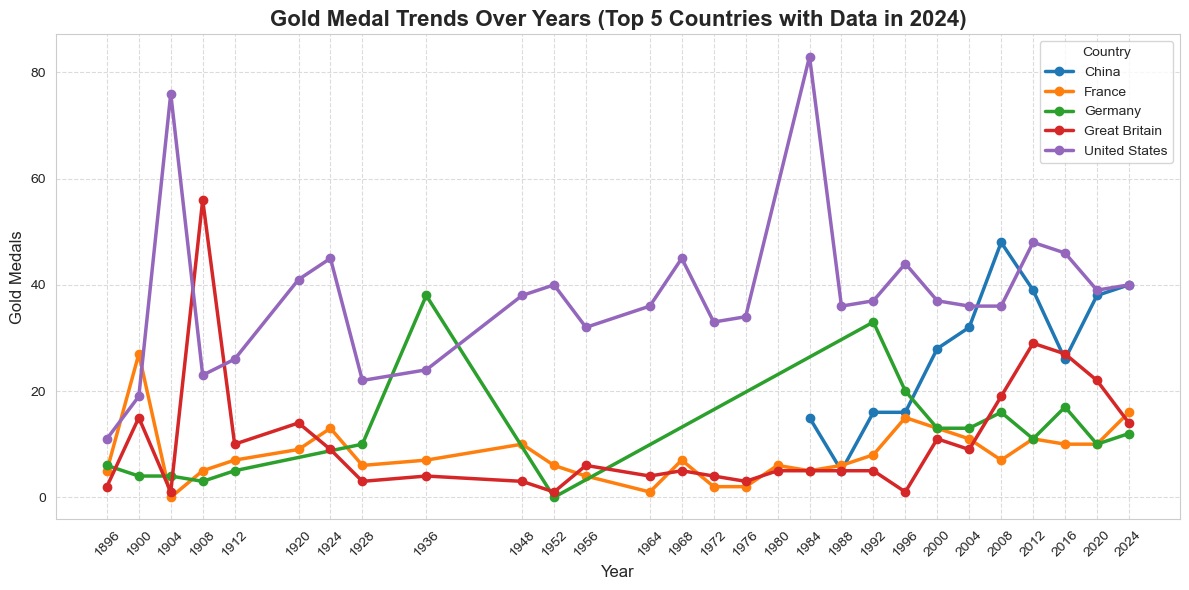

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display settings and style
plt.rcParams['axes.unicode_minus'] = False  
sns.set_style("whitegrid")

# Load data
medal_data = pd.read_csv(r"C:\Users\10759\Desktop\summerOly_medal_counts.csv")
countries = ['France', 'Great Britain', 'Germany', 'United States', 'China']
filtered_data = medal_data[medal_data['NOC'].isin(countries)]

# Ensure countries have 2024 data
countries_with_2024_data = filtered_data[filtered_data['Year'] == 2024]['NOC'].unique()
final_data = filtered_data[filtered_data['NOC'].isin(countries_with_2024_data)]

# Group by country and year, summing gold medals
grouped_data = final_data.groupby(['NOC', 'Year'])['Gold'].sum().reset_index()

# Create line plot
plt.figure(figsize=(12, 6))

# Plot line for each country
for country in grouped_data['NOC'].unique():
    country_data = grouped_data[grouped_data['NOC'] == country]
    plt.plot(country_data['Year'], country_data['Gold'],
             marker='o',
             label=country,
             linewidth=2.5)

# Set chart title and labels
plt.title('Gold Medal Trends Over Years (Top 5 Countries with Data in 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Gold Medals', fontsize=12)

# Add legend
plt.legend(title='Country', fontsize=10)

# Adjust x-axis ticks to show all years
plt.xticks(grouped_data['Year'].unique(), rotation=45)

# Display grid lines
plt.grid(True, linestyle='--', alpha=0.7)

# Auto-adjust layout
plt.tight_layout()

# Save image
plt.savefig('gold_medal_trends_top5.png', dpi=300, bbox_inches='tight')

# Display chart
plt.show()